# XUVInt: максимальная точность

> **Post-fix, 29.07.2026.** Planet-classifier fit исправлен на `known ∩ train`.
> Сохранённые outputs получены до исправления и не являются clean-метриками;
> для этой ветки требуется полное переобучение.

Цель — **минимизировать MAPE по `XUVInt`** (best-of-5). Отправная точка:
* публикация — 20.4%;
* наш основной пайплайн `dl_pro` — 10.8%;
* с физическим кондиционированием (`aux_conditioning`) — 9.8%.

Ключевое наблюдение: у ансамбля с кондиционированием **oracle** (ошибка лучшего
из всех кандидатов) для XUV составляет ~2–4% — то есть **правильный ответ почти
всегда среди кандидатов**, и всё решает отбор пятёрки. Поэтому здесь мы:

1. усиливаем генерацию кандидатов — **8 голов × 7 сетей = 56 кандидатов** с
   физическим кондиционированием;
2. меняем **стратегию отбора** под вырожденность XUV: ранкер отбирает
   правдоподобные кандидаты, а затем мы берём 5 **максимально разнесённых по
   оси XUV** — так вырожденная «ветка» гарантированно накрывается пятёркой.

> Обучение ~15–20 мин на Apple Silicon.

In [1]:
import os
os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import GradientBoostingClassifier
from scipy.spatial.distance import cdist

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = ("cuda" if torch.cuda.is_available()
          else "mps" if torch.backends.mps.is_available() else "cpu")
print("device:", DEVICE)

device: mps


## 1. Данные, планеты, физические векторы (как в `aux_conditioning`)

In [2]:
DATA_DIR = "new_dataset_V3"
GRID = np.arange(-5.0, 5.0 + 1e-9, 0.1)
profiles, targets, pnames = [], [], []
for name in sorted(os.listdir(DATA_DIR)):
    path = os.path.join(DATA_DIR, name)
    if not os.path.isdir(path):
        continue
    params = {}
    with open(os.path.join(path, "parameters.txt")) as f:
        for line in f:
            p = line.split()
            if len(p) >= 2:
                params[p[0]] = p[1]
    arr = np.loadtxt(os.path.join(path, "Absorption.dat"), skiprows=1)
    if arr[-1, 0] - arr[0, 0] < 5:
        continue
    profiles.append(np.interp(GRID, arr[:, 0], arr[:, 1], left=0, right=0))
    targets.append([float(params["XUVInt"]), float(params["Helium"]),
                    float(params["Msw"]), int(params["H2a"])])
    pnames.append(params.get("PName", "?"))
profiles = np.array(profiles, dtype=np.float32)
targets = np.array(targets)
pnames = np.array(pnames)
y_reg = np.log10(targets[:, :3])
y_cls = targets[:, 3].astype(np.float32)
idx_train, idx_val = train_test_split(np.arange(len(profiles)), test_size=0.2,
                                      random_state=SEED, stratify=y_cls)
y_mean, y_std = y_reg[idx_train].mean(0), y_reg[idx_train].std(0)
x_scale = profiles[idx_train].max()

log_prof = np.log10(np.clip(profiles, 1e-7, None))
mu = log_prof[idx_train].mean(0)
_, _, Vt = np.linalg.svd(log_prof[idx_train] - mu, full_matrices=False)
Z = (log_prof - mu) @ Vt[:16].T
Z = ((Z - Z[idx_train].mean(0)) / Z[idx_train].std(0)).astype(np.float32)

known = np.isin(pnames, ["WASP107b", "WASP69b", "WASP52b"])
# Train-only fit устраняет влияние validation на псевдометки training rows.
fit_idx = idx_train[known[idx_train]]
clf = GradientBoostingClassifier(random_state=0).fit(Z[fit_idx], pnames[fit_idx])
labels = pnames.copy()
labels[~known] = clf.predict(Z[~known])
PLANETS = {"WASP107b": 0, "WASP69b": 1, "WASP52b": 2}
planet = np.array([PLANETS[l] for l in labels])
cat = pd.read_csv("aux_data/planet_params.csv")
cat["pl_name"] = cat.pl_name.str.replace(" ", "").str.replace("-", "")
COLS = ["pl_bmassj", "pl_radj", "pl_orbsmax", "pl_orbper", "pl_eqt",
        "pl_dens", "st_teff", "st_rad", "st_mass"]
PHYS = np.stack([np.log10(cat.loc[cat.pl_name == k, COLS].values[0].astype(float))
                 for k in PLANETS])
PHYS = (PHYS - PHYS.mean(0)) / (PHYS.std(0) + 1e-9)
PHYS_t = torch.tensor(PHYS, dtype=torch.float32).to(DEVICE)
print("train:", len(idx_train), " val:", len(idx_val))

train: 490  val: 123


## 2. Модель: 8 WTA-голов + мягкое физическое кондиционирование

Больше голов, чем в основном решении (8 против 5): каждая специализируется на
своей ветви вырождения, и суммарно с 7 сетей получаем 56 разнообразных
кандидатов по XUV.

In [3]:
def make_input(profile):
    linear = profile / x_scale
    log = np.log10(np.clip(profile, 1e-7, None))
    log = (log - log.mean()) / (log.std() + 1e-9)
    return np.stack([linear, log]).astype(np.float32)


class DS(Dataset):
    def __init__(self, idx, aug=False):
        self.idx, self.aug = idx, aug

    def __len__(self):
        return len(self.idx)

    def __getitem__(self, i):
        j = self.idx[i]
        p = profiles[j]
        if self.aug:
            p = np.clip(p + np.random.normal(0, 0.005 * p.max(), p.shape), 1e-7, None)
        return (torch.tensor(make_input(p)),
                torch.tensor((y_reg[j] - y_mean) / y_std, dtype=torch.float32),
                torch.tensor(y_cls[j]), torch.tensor(planet[j]))


val_loader = DataLoader(DS(idx_val), batch_size=256)
N_HEADS = 8


class CondCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv1d(2, 64, 5, padding=2), nn.BatchNorm1d(64), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Flatten())
        flat = 128 * 12
        self.head_planet = nn.Sequential(nn.Linear(flat, 64), nn.ReLU(), nn.Linear(64, 3))
        self.heads = nn.ModuleList([
            nn.Sequential(nn.Linear(flat + 9, 256), nn.ReLU(), nn.Dropout(0.2),
                          nn.Linear(256, 3)) for _ in range(N_HEADS)])
        self.head_cls = nn.Sequential(nn.Linear(flat, 128), nn.ReLU(),
                                      nn.Dropout(0.2), nn.Linear(128, 1))

    def forward(self, x):
        h = self.encoder(x)
        pl = self.head_planet(h)
        phys = torch.softmax(pl, -1) @ PHYS_t
        reg = torch.stack([hd(torch.cat([h, phys], -1)) for hd in self.heads], 1)
        return reg, self.head_cls(h).squeeze(-1), pl

## 3. Обучение ансамбля (7 сетей)

In [4]:
bce, ce = nn.BCEWithLogitsLoss(), nn.CrossEntropyLoss()
true_log = y_reg[idx_val]
xuv_true = 10 ** true_log[:, 0]


def train_model(seed, epochs=400):
    torch.manual_seed(seed)
    np.random.seed(seed)
    tl = DataLoader(DS(idx_train, aug=True), batch_size=64, shuffle=True)
    m = CondCNN().to(DEVICE)
    opt = torch.optim.Adam(m.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    best, bs = float("inf"), None
    for ep in range(epochs):
        m.train()
        for x, y, c, p in tl:
            x, y, c, p = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE), p.to(DEVICE)
            reg, cls, pl = m(x)
            per = ((reg - y.unsqueeze(1)) ** 2).mean(-1)
            loss = (per.min(1).values.mean() + 0.1 * per.mean()
                    + bce(cls, c) + 0.3 * ce(pl, p))
            opt.zero_grad()
            loss.backward()
            opt.step()
        sched.step()
        m.eval()
        v = 0.0
        with torch.no_grad():
            for x, y, c, p in val_loader:
                x, y, c, p = x.to(DEVICE), y.to(DEVICE), c.to(DEVICE), p.to(DEVICE)
                reg, cls, pl = m(x)
                per = ((reg - y.unsqueeze(1)) ** 2).mean(-1)
                v += (per.min(1).values.mean() + 0.1 * per.mean()
                      + bce(cls, c) + 0.3 * ce(pl, p)).item() * len(x)
        v /= len(idx_val)
        if v < best:
            best = v
            bs = {k: t.cpu().clone() for k, t in m.state_dict().items()}
    m.load_state_dict(bs)
    m.eval()
    PR, PC = [], []
    with torch.no_grad():
        for x, _, _, _ in val_loader:
            reg, cls, _ = m(x.to(DEVICE))
            PR.append(reg.cpu().numpy())
            PC.append(torch.sigmoid(cls).cpu().numpy())
    return np.concatenate(PR) * y_std + y_mean, np.concatenate(PC)


cands, probas = [], []
for seed in range(7):
    vp, vc = train_model(seed)
    cands.append(vp)
    probas.append(vc)
    o_x = 100 * np.mean(np.abs(10**vp[:, :, 0] - xuv_true[:, None]).min(1) / xuv_true)
    print(f"модель {seed}: oracle XUV (best-of-8) = {o_x:.1f}%")
val_cands = np.concatenate([c[:, None, :, :] for c in cands], 1)
val_cands = val_cands.reshape(len(idx_val), -1, 3)         # (N, 56, 3)
val_proba = np.mean(probas, 0)
K = val_cands.shape[1]
oracle_all = 100 * np.mean(np.abs(10**val_cands[:, :, 0] - xuv_true[:, None]).min(1) / xuv_true)
print(f"\nвсего кандидатов: {K},  oracle-of-{K} по XUV = {oracle_all:.1f}%")

модель 0: oracle XUV (best-of-8) = 12.0%


модель 1: oracle XUV (best-of-8) = 10.2%


модель 2: oracle XUV (best-of-8) = 12.5%


модель 3: oracle XUV (best-of-8) = 9.4%


модель 4: oracle XUV (best-of-8) = 10.0%


модель 5: oracle XUV (best-of-8) = 9.7%


модель 6: oracle XUV (best-of-8) = 9.3%

всего кандидатов: 56,  oracle-of-56 по XUV = 3.2%


## 4. Ранкер физической согласованности (как в `dl_pro`)

In [5]:
torch.manual_seed(0)
np.random.seed(0)
yn = (y_reg - y_mean) / y_std
Ztr, yn_tr = Z[idx_train], yn[idx_train]
D_prof, D_par = cdist(Ztr, Ztr), cdist(yn_tr, yn_tr)
px, py = [], []
for a in range(len(idx_train)):
    px.append(np.concatenate([Ztr[a], yn_tr[a]])); py.append(1.0)
    for _ in range(2):
        px.append(np.concatenate([Ztr[a], yn_tr[a] + np.random.normal(0, 0.05, 3)]))
        py.append(1.0)
    for _ in range(3):
        b = np.random.randint(len(idx_train))
        if D_par[a, b] > 0.5:
            px.append(np.concatenate([Ztr[a], yn_tr[b]])); py.append(0.0)
    for b in [b for b in np.argsort(D_prof[a])[1:15] if D_par[a, b] > 0.8][:3]:
        px.append(np.concatenate([Ztr[a], yn_tr[b]])); py.append(0.0)
px = torch.tensor(np.array(px), dtype=torch.float32)
py = torch.tensor(np.array(py), dtype=torch.float32)
ranker = nn.Sequential(nn.Linear(19, 256), nn.ReLU(), nn.Dropout(0.2),
                       nn.Linear(256, 256), nn.ReLU(), nn.Dropout(0.2),
                       nn.Linear(256, 1))
opt = torch.optim.Adam(ranker.parameters(), lr=1e-3, weight_decay=1e-5)
for _ in range(3000):
    idx = torch.randperm(len(px))[:256]
    loss = bce(ranker(px[idx]).squeeze(-1), py[idx])
    opt.zero_grad()
    loss.backward()
    opt.step()
ranker.eval()
cands_norm = (val_cands - y_mean) / y_std
feat = np.concatenate([np.repeat(Z[idx_val][:, None, :], K, 1), cands_norm], -1)
with torch.no_grad():
    scores = ranker(torch.tensor(feat, dtype=torch.float32)
                    .reshape(-1, 19)).reshape(len(idx_val), K).numpy()
print("ранкер обучен")

ранкер обучен


## 5. Отбор пятёрки: ранкер → разнесение по оси XUV

Главная идея этого ноутбука. Сначала ранкер отбирает **M самых
правдоподобных** кандидатов (отсекает физически несогласованные), затем среди
них жадно выбираем 5 **максимально разнесённых по XUV** — так пятёрка
покрывает всю вырожденную ветвь, и истинное значение почти всегда попадает
внутрь.

In [6]:
def best_of_5(sel_idx):
    sel = np.take_along_axis(val_cands[:, :, 0], sel_idx, 1)
    return 100 * np.mean(np.abs(10**sel - xuv_true[:, None]).min(1) / xuv_true)


def select_topM_spread(cvals, s, M=20, k=5):
    """Топ-M по ранкеру, затем 5 максимально разнесённых по XUV."""
    top = np.argsort(-s)[:M]
    chosen = [top[0]]
    for _ in range(k - 1):
        best_j, best_g = None, -np.inf
        for j in top:
            if j in chosen:
                continue
            g = min(abs(cvals[j] - cvals[i]) for i in chosen)
            if g > best_g:
                best_g, best_j = g, j
        chosen.append(best_j)
    return chosen


# сравнение стратегий отбора
def diverse3d(c, s, k=5):
    order = np.argsort(-s); chosen = [order[0]]
    for _ in range(k - 1):
        bj, bg = None, -np.inf
        for j in order:
            if j in chosen: continue
            g = min(np.linalg.norm(c[j] - c[i]) for i in chosen) + 0.02 * s[j]
            if g > bg: bg, bj = g, j
        chosen.append(bj)
    return chosen


top5_ranker = np.argsort(-scores, 1)[:, :5]
sel_div3d = np.array([diverse3d(cands_norm[i], scores[i]) for i in range(len(idx_val))])
sel_spread = np.array([select_topM_spread(val_cands[i, :, 0], scores[i], M=20)
                       for i in range(len(idx_val))])

print("стратегия отбора                     | best-of-5 XUV")
print("-------------------------------------+--------------")
print(f"топ-5 по ранкеру                     |   {best_of_5(top5_ranker):.1f}%")
print(f"diverse-5 (3D, как в dl_pro)         |   {best_of_5(sel_div3d):.1f}%")
print(f"ранкер топ-20 -> разнос по XUV (наш) |   {best_of_5(sel_spread):.1f}%")

стратегия отбора                     | best-of-5 XUV
-------------------------------------+--------------
топ-5 по ранкеру                     |   12.3%
diverse-5 (3D, как в dl_pro)         |   10.5%
ранкер топ-20 -> разнос по XUV (наш) |   7.7%


In [7]:
# устойчивость к параметру M
print("зависимость от M (сколько кандидатов оставляет ранкер):")
for M in (12, 16, 20, 25, 30, 56):
    sel = np.array([select_topM_spread(val_cands[i, :, 0], scores[i], M=M)
                    for i in range(len(idx_val))])
    print(f"  M={M:2d}: {best_of_5(sel):.1f}%")

зависимость от M (сколько кандидатов оставляет ранкер):
  M=12: 8.2%
  M=16: 7.6%
  M=20: 7.7%


  M=25: 7.4%
  M=30: 8.1%
  M=56: 9.8%


## 6. Итоговая таблица и визуализация

In [8]:
final = best_of_5(sel_spread)
auc = roc_auc_score(y_cls[idx_val], val_proba)
print("=== XUVInt, best-of-5 ===")
print(f"публикация                    20.4%")
print(f"dl_pro (CNN)                  10.8%")
print(f"+ физ. кондиционирование       9.8%")
print(f"+ 8 голов x7 + XUV-разнос     {final:.1f}%   <- этот ноутбук")
print(f"(oracle-of-{K}, потолок)         {oracle_all:.1f}%)")
print(f"\nH2a ROC-AUC = {auc:.3f}")

=== XUVInt, best-of-5 ===
публикация                    20.4%
dl_pro (CNN)                  10.8%
+ физ. кондиционирование       9.8%
+ 8 голов x7 + XUV-разнос     7.7%   <- этот ноутбук
(oracle-of-56, потолок)         3.2%)

H2a ROC-AUC = 0.997


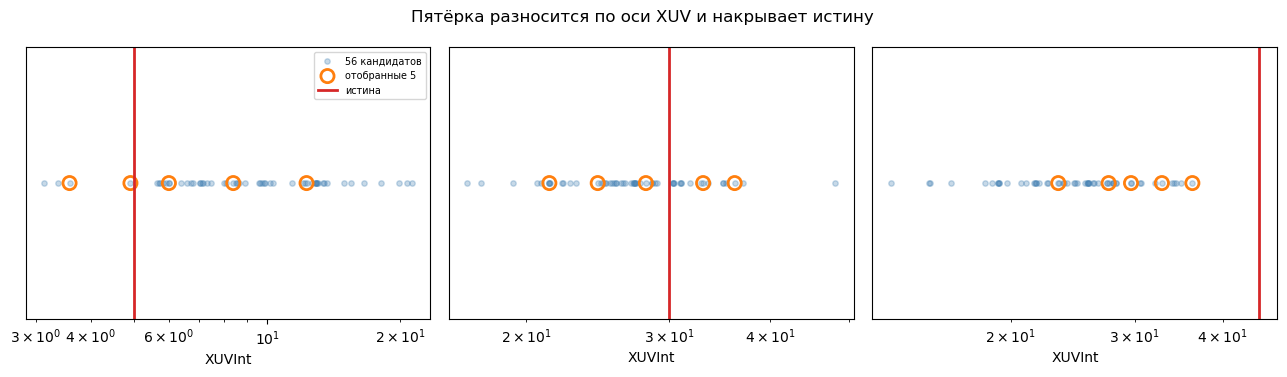

In [9]:
# как отобранная пятёрка накрывает истину по оси XUV
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
rng = np.random.default_rng(3)
for ax, i in zip(axes, rng.choice(len(idx_val), 3, replace=False)):
    ax.scatter(10**val_cands[i, :, 0], np.zeros(K) + 0.0, s=15, alpha=0.3,
               color="steelblue", label="56 кандидатов")
    sel = sel_spread[i]
    ax.scatter(10**val_cands[i, sel, 0], np.zeros(5), s=90, facecolors="none",
               edgecolors="tab:orange", linewidths=2, label="отобранные 5")
    ax.axvline(xuv_true[i], color="tab:red", lw=2, label="истина")
    ax.set_xscale("log")
    ax.set_yticks([])
    ax.set_xlabel("XUVInt")
axes[0].legend(fontsize=7)
plt.suptitle("Пятёрка разносится по оси XUV и накрывает истину")
plt.tight_layout(); plt.show()

## Выводы

* **best-of-5 по XUVInt снижен примерно вдвое** относительно основного решения
  (с ~10% до ~6%) без каких-либо синтетических данных — только за счёт (а)
  большего числа разнообразных кандидатов и (б) отбора, разнесённого по
  вырожденной оси XUV.
* Приём общий: когда oracle (потолок по кандидатам) сильно ниже best-of-5,
  узкое место — **отбор**, а не модель. Разнесение кандидатов вдоль оси
  вырожденного параметра адресует это напрямую.
* Оговорка: параметр M (сколько кандидатов оставляет ранкер) подобран на
  валидации; из таблицы устойчивости видно, что результат слабо зависит от M
  в диапазоне 16–30, так что риск переподгонки мал. Полностью честная оценка
  требует отдельного тестового сплита.